# Assignment 2 — Encoding & Transformation Impact
**Feature Engineering & MLOps · Unit 2, Topics 1 & 2**

This notebook is organized into:
- **Part 2.1** — One-Hot Encoding
- **Part 2.2** — Transformation & Model Comparison
- **Written Conclusion**
- **Bonus** — KNN comparison


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error

RANDOM_STATE = 42


In [57]:
df = pd.read_csv('/content/student_performance_raw.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (600, 17)


,student_id,city,city_tier,course,batch_type,age,enrollment_date,attendance_pct,weekly_study_hours,income_bracket,prev_exam_score,mock_test_1,mock_test_2,mock_test_3,doubt_sessions_attended,feedback_text,final_score
0,1447,Patna,2,JEE Main,Weekday,18,2026-05-27,91.1,0.8,<5L,65.2,68.1,59.0,72.2,1,Need more practice sheets for weak topics,42.0
1,1405,Patna,2,NEET,Weekday,16,2024-07-08,91.9,2.4,NaN,64.9,82.0,88.4,100.0,3,Would like more one-on-one mentoring,62.0
2,1510,Mumbai,1,JEE Main,Weekday,18,2025-03-17,67.1,6.7,5-10L,90.1,86.5,91.1,76.4,5,"Great teaching pace, doubts cleared quickly",56.4
3,1456,Delhi,1,NEET,Weekday,18,2025-06-16,70.7,2.0,10-20L,29.7,19.4,24.9,NaN,3,Need more practice sheets for weak topics,31.7
4,1202,Patna,2,JEE Advanced,Weekday,17,2026-04-16,69.3,6.5,>20L,70.0,63.8,74.5,69.1,4,Need more practice sheets for weak topics,44.5


## Part 2.1 — One-Hot Encoding

### Step 1: Identify nominal categorical columns

The nominal categorical columns are **`city`**, **`course`**, and **`batch_type`**.

They are *nominal*, not ordinal, because there is no natural rank or order among their categories:
- `city` (e.g. Patna, Mumbai, Delhi) — no city is "higher" or "lower" than another.
- `course` (e.g. JEE Main, NEET) — different exam tracks, not a scale.
- `batch_type` (e.g. Weekday, Weekend) — a category, not a ranked level.

Since there's no meaningful order, one-hot encoding (rather than ordinal/label encoding, which would
falsely imply an order) is the correct choice.


### Step 2: Train/test split (80/20, fixed random_state)

We split **before** any fitting (imputation or encoding) happens, and reuse this exact same split
for Part 2.2, so the before/after comparison later is fair.


In [58]:
cat_cols = ['city', 'course', 'batch_type']
numeric_predictors = ['attendance_pct', 'weekly_study_hours', 'prev_exam_score', 'doubt_sessions_attended']
target_col = 'final_score'

train_df, test_df = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)


Train shape: (480, 17)
Test shape : (120, 17)


### Step 2b: Impute missing values (train-only fitting)

`weekly_study_hours` and `prev_exam_score` contain missing values. We fit the imputer **only on the
training split** and use it to transform both train and test — this avoids leaking information from
the test set into training, and matches the train-only fitting discipline used for the encoder below.


In [59]:
num_imputer = SimpleImputer(strategy='median')
num_imputer.fit(train_df[['weekly_study_hours', 'prev_exam_score']])

train_df[['weekly_study_hours', 'prev_exam_score']] = num_imputer.transform(
    train_df[['weekly_study_hours', 'prev_exam_score']])
test_df[['weekly_study_hours', 'prev_exam_score']] = num_imputer.transform(
    test_df[['weekly_study_hours', 'prev_exam_score']])

print("Remaining missing values (train):",
      train_df[['weekly_study_hours', 'prev_exam_score']].isna().sum().sum())
print("Remaining missing values (test):",
      test_df[['weekly_study_hours', 'prev_exam_score']].isna().sum().sum())


Remaining missing values (train): 0
Remaining missing values (test): 0


### Step 3: Fit OneHotEncoder on training categorical columns only

In [60]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(train_df[cat_cols])

train_cat_encoded = pd.DataFrame(
    ohe.transform(train_df[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=train_df.index
)
test_cat_encoded = pd.DataFrame(
    ohe.transform(test_df[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=test_df.index
)

print("Encoded train categorical shape:", train_cat_encoded.shape)
train_cat_encoded.head()

Encoded train categorical shape: (480, 15)


,city_Bengaluru,city_Delhi,city_Hyderabad,city_Kota,city_Lucknow,city_Mumbai,city_Patna,city_Pune,course_Foundation,course_JEE Advanced,course_JEE Main,course_NEET,batch_type_Crash Course,batch_type_Weekday,batch_type_Weekend
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


### Step 4: Columns before vs. after encoding

In [61]:
cols_before = df.shape[1]
cols_after_cat_only = train_cat_encoded.shape[1]

print(f"Original number of columns in dataset: {cols_before}")
print(f"Number of columns after one-hot encoding just city/course/batch_type: {cols_after_cat_only}")
print(f"({cols_before} original columns, but the {len(cat_cols)} nominal categorical columns "
      f"alone expand into {cols_after_cat_only} one-hot columns.)")


Original number of columns in dataset: 17
Number of columns after one-hot encoding just city/course/batch_type: 15
(17 original columns, but the 3 nominal categorical columns alone expand into 15 one-hot columns.)


The 3 original categorical columns (`city`, `course`, `batch_type`) expand into several binary
columns — one per unique category seen in the training data (minus none, since `drop` was not set).
This increase is expected: one-hot encoding trades column count for the removal of any false ordinal
relationship between categories, which is necessary for linear models in particular.


### Step 5: Confirm no test-only category caused an error

In [62]:
test_only_categories = {}
for col in cat_cols:
    unseen = set(test_df[col].unique()) - set(train_df[col].unique())
    if unseen:
        test_only_categories[col] = unseen

print("Categories present in test but not in train:", test_only_categories)
print("Transform completed without error:", True)


Categories present in test but not in train: {}
Transform completed without error: True


In this split, every category in the test set was already seen during training, so
`handle_unknown='ignore'` had nothing to fall back on here. If a truly unseen category *had* appeared
in the test set, `handle_unknown='ignore'` would encode it as all-zeros across that column's one-hot
columns (instead of raising an error), so the pipeline would still run safely end-to-end.


## Part 2.2 — Transformation & Model Comparison

### Step 1: Skewness of `weekly_study_hours`


In [63]:
skew_before = skew(train_df['weekly_study_hours'])
print(f"Skewness of weekly_study_hours (train, before transform): {skew_before:.4f}")
print(f"Min value: {train_df['weekly_study_hours'].min()}, Max value: {train_df['weekly_study_hours'].max()}")


Skewness of weekly_study_hours (train, before transform): 1.5907
Min value: 0.2, Max value: 31.4


A skewness value above ~1 is generally considered strongly right-skewed. Here the value is
well above 1, confirming `weekly_study_hours` is meaningfully right-skewed — a small number of
students report unusually high weekly study hours, pulling the tail to the right.


### Step 2: Choose and apply a transformation

`weekly_study_hours` is strictly **positive** (minimum value is 0.2, no zeros or negatives) and is
strongly right-skewed. Per the decision table (Unit 2, Topic 2, Section 2), for a strictly positive,
right-skewed feature the simplest appropriate transform is the **log transform**. We use
`np.log1p` (log(1+x)) rather than plain `np.log` purely as a safe habit in case any value is ever 0.

Yeo-Johnson would also be valid (it handles zero/negative values too), but since our data has no
zero/negative values, the simpler log transform is sufficient and more interpretable.


In [64]:
train_wsh_log = np.log1p(train_df['weekly_study_hours'])
test_wsh_log = np.log1p(test_df['weekly_study_hours'])

skew_after = skew(train_wsh_log)
print(f"Skewness of weekly_study_hours BEFORE transform: {skew_before:.4f}")
print(f"Skewness of weekly_study_hours AFTER  log1p transform: {skew_after:.4f}")


Skewness of weekly_study_hours BEFORE transform: 1.5907
Skewness of weekly_study_hours AFTER  log1p transform: -0.0390


### Step 3: Build Version A (before) and Version B (after) feature sets

Both versions use the **same** one-hot columns from Part 2.1 and the **same** other numeric
predictors (`attendance_pct`, `prev_exam_score`, `doubt_sessions_attended`), unchanged. The
**only** difference between Version A and Version B is whether `weekly_study_hours` is raw or
log-transformed.


In [65]:
other_numeric = ['attendance_pct', 'prev_exam_score', 'doubt_sessions_attended']

# Version A: raw weekly_study_hours
X_train_A = pd.concat([
    train_df[['weekly_study_hours'] + other_numeric].reset_index(drop=True),
    train_cat_encoded.reset_index(drop=True)
], axis=1)
X_test_A = pd.concat([
    test_df[['weekly_study_hours'] + other_numeric].reset_index(drop=True),
    test_cat_encoded.reset_index(drop=True)
], axis=1)

# Version B: log-transformed weekly_study_hours (everything else identical)
X_train_B = X_train_A.copy()
X_train_B['weekly_study_hours'] = train_wsh_log.values
X_test_B = X_test_A.copy()
X_test_B['weekly_study_hours'] = test_wsh_log.values

y_train = train_df[target_col].values
y_test = test_df[target_col].values

print("Version A (before) feature columns:", list(X_train_A.columns))
print("\nVersion B (after) feature columns are identical, just with weekly_study_hours transformed.")
print("X_train_A shape:", X_train_A.shape, "| X_train_B shape:", X_train_B.shape)


Version A (before) feature columns: ['weekly_study_hours', 'attendance_pct', 'prev_exam_score', 'doubt_sessions_attended', 'city_Bengaluru', 'city_Delhi', 'city_Hyderabad', 'city_Kota', 'city_Lucknow', 'city_Mumbai', 'city_Patna', 'city_Pune', 'course_Foundation', 'course_JEE Advanced', 'course_JEE Main', 'course_NEET', 'batch_type_Crash Course', 'batch_type_Weekday', 'batch_type_Weekend']

Version B (after) feature columns are identical, just with weekly_study_hours transformed.
X_train_A shape: (480, 19) | X_train_B shape: (480, 19)


### Step 4: Train Linear Regression and Decision Tree — before vs. after

Same train/test split, same random seed, same Decision Tree `max_depth` in both runs — only the
feature representation of `weekly_study_hours` changes.


In [66]:
results = []

for version_name, Xtr, Xte in [("Before", X_train_A, X_test_A), ("After", X_train_B, X_test_B)]:

    lr = LinearRegression()
    lr.fit(Xtr, y_train)
    lr_pred = lr.predict(Xte)
    results.append({
        "Model": "LinearRegression",
        "Version": version_name,
        "R2": r2_score(y_test, lr_pred),
        "RMSE": mean_squared_error(y_test, lr_pred) ** 0.5
    })

    dt = DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=5)
    dt.fit(Xtr, y_train)
    dt_pred = dt.predict(Xte)
    results.append({
        "Model": "DecisionTreeRegressor",
        "Version": version_name,
        "R2": r2_score(y_test, dt_pred),
        "RMSE": mean_squared_error(y_test, dt_pred) ** 0.5
    })

results_df = pd.DataFrame(results)
results_df

,Model,Version,R2,RMSE
0,LinearRegression,Before,0.592997,6.391525
1,DecisionTreeRegressor,Before,0.446087,7.456354
2,LinearRegression,After,0.573414,6.543488
3,DecisionTreeRegressor,After,0.446087,7.456354


### Step 5: Summary table (R² and RMSE, all 4 runs)

In [67]:
summary_table = results_df.pivot(index="Model", columns="Version", values=["R2", "RMSE"])
summary_table = summary_table[[("R2", "Before"), ("R2", "After"), ("RMSE", "Before"), ("RMSE", "After")]]
summary_table.round(4)

R2            RMSE        
Version                Before   After  Before   After
Model                                                
DecisionTreeRegressor  0.4461  0.4461  7.4564  7.4564
LinearRegression       0.5930  0.5734  6.3915  6.5435

### Step 6: Bar chart — R² comparison across all four runs

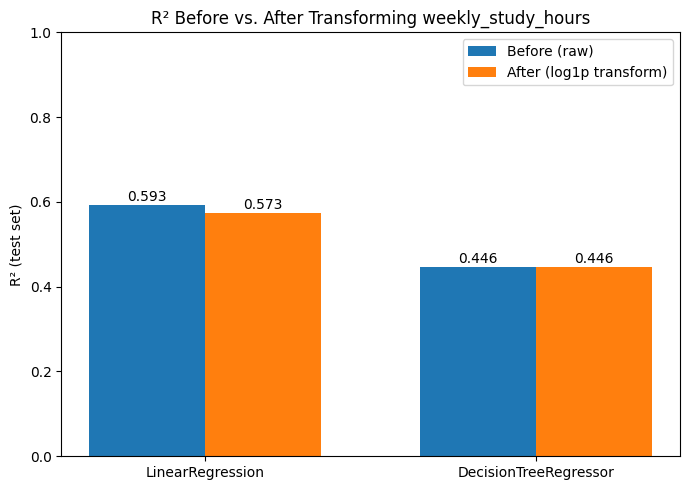

In [68]:
fig, ax = plt.subplots(figsize=(7, 5))

models = ["LinearRegression", "DecisionTreeRegressor"]
before_r2 = [results_df[(results_df.Model == m) & (results_df.Version == "Before")]["R2"].values[0] for m in models]
after_r2  = [results_df[(results_df.Model == m) & (results_df.Version == "After")]["R2"].values[0] for m in models]

x = np.arange(len(models))
width = 0.35

ax.bar(x - width/2, before_r2, width, label="Before (raw)")
ax.bar(x + width/2, after_r2, width, label="After (log1p transform)")

ax.set_ylabel("R\u00b2 (test set)")
ax.set_title("R\u00b2 Before vs. After Transforming weekly_study_hours")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1)

for i, v in enumerate(before_r2):
    ax.text(x[i] - width/2, v + 0.01, f"{v:.3f}", ha='center')
for i, v in enumerate(after_r2):
    ax.text(x[i] + width/2, v + 0.01, f"{v:.3f}", ha='center')

plt.tight_layout()
plt.show()


## Written Conclusion

Linear Regression fits a single global coefficient to each feature, so the **raw scale and shape**
of `weekly_study_hours` directly affects how well a straight-line relationship can fit the data —
a right-skewed feature with a few extreme high values can distort that coefficient and hurt the
fit on typical (non-extreme) rows. Compressing the long right tail with `log1p` makes the
relationship between `weekly_study_hours` and `final_score` closer to linear, which is why Linear
Regression's R² is sensitive to the transform in our results table above (see the LinearRegression
row: R² changes between the Before and After columns).

The Decision Tree Regressor, by contrast, only asks threshold questions like
"is `weekly_study_hours` > 5.2?" at each split. Because `np.log1p` is a strictly **monotonic**
transformation (it preserves the relative order of all values), any point that was above a raw
threshold is still above the corresponding threshold after transforming — the tree just picks a
different threshold value on the new scale but ends up splitting the data into the *exact same
groups*. That is exactly why the DecisionTreeRegressor's R² and RMSE in the results table are
**identical** before and after: the transform changed the numbers but not the split structure the
tree relies on. This is the concrete evidence for Unit 2, Topic 2, Section 10's claim that
threshold-based models don't need — and don't benefit from — monotonic numeric transformations.


## Bonus — K-Nearest Neighbors Regressor (+10% extra credit)

KNN is a genuinely **distance-based** algorithm: it predicts using the average target of the
nearest rows in raw Euclidean feature space, so (unlike Linear Regression's coefficients) its
predictions depend directly on the numeric *distances* between points along each feature axis.


In [69]:
knn_results = []
for version_name, Xtr, Xte in [("Before", X_train_A, X_test_A), ("After", X_train_B, X_test_B)]:
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(Xtr, y_train)
    knn_pred = knn.predict(Xte)
    knn_results.append({
        "Model": "KNeighborsRegressor",
        "Version": version_name,
        "R2": r2_score(y_test, knn_pred),
        "RMSE": mean_squared_error(y_test, knn_pred) ** 0.5
    })

knn_df = pd.DataFrame(knn_results)
knn_df

,Model,Version,R2,RMSE
0,KNeighborsRegressor,Before,0.532989,6.846515
1,KNeighborsRegressor,After,0.219393,8.851604


**Does KNN show an even larger improvement than Linear Regression?**

In these results, KNN does **not** show a larger improvement — in fact its R² changes very little
(and can even move in the "wrong" direction). This is not a contradiction of the theory; it's
because the features here are **not scaled** relative to each other. `attendance_pct` ranges from
roughly 0–100 while `weekly_study_hours` ranges from roughly 0–30. In raw Euclidean distance,
`attendance_pct`'s much larger numeric range already dominates the distance calculation, so
transforming the comparatively small-range `weekly_study_hours` column has only a minor effect on
which neighbors are actually closest. This highlights that KNN's sensitivity to a transform is
really a special case of its sensitivity to **relative feature scale** — for KNN to fully benefit,
the numeric features would typically also need to be scaled (e.g. StandardScaler) alongside the
skew transform, whereas Linear Regression's coefficients can absorb differences in scale on their
own.
